<a href="https://colab.research.google.com/github/Al-FaizAli/Time-Series-Analysis-and-Forecasting-using-LSTM/blob/main/temp_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [ ]:
df=pd.read_csv('/content/1996_19.32_72.72.csv')
# df=pd.read_csv('/content/1996_19.32_72.72.csv',index_col='Time', parse_dates=['Time'])

In [ ]:
df.shape

(8784, 2)

In [ ]:
df.head(10)

,Time,Temperature
0,1996-01-01 00:00:00,25.410059
1,1996-01-01 01:00:00,25.424219
2,1996-01-01 02:00:00,25.421625
3,1996-01-01 03:00:00,25.404688
4,1996-01-01 04:00:00,25.407556
5,1996-01-01 05:00:00,25.422205
6,1996-01-01 06:00:00,25.310571
7,1996-01-01 07:00:00,25.318506
8,1996-01-01 08:00:00,25.292566
9,1996-01-01 09:00:00,25.297876


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Time         8784 non-null   object 
 1   Temperature  8784 non-null   float64
dtypes: float64(1), object(1)
memory usage: 137.4+ KB


In [ ]:
df.isnull().sum()

,0
Time,0
Temperature,0


In [ ]:
df.describe()

,Temperature
count,8784.000000
mean,27.184828
std,1.324216
min,24.662683
25%,26.287546
50%,27.354898
75%,28.280977
max,29.240381


In [ ]:
df['Time']=pd.to_datetime(df['Time'])

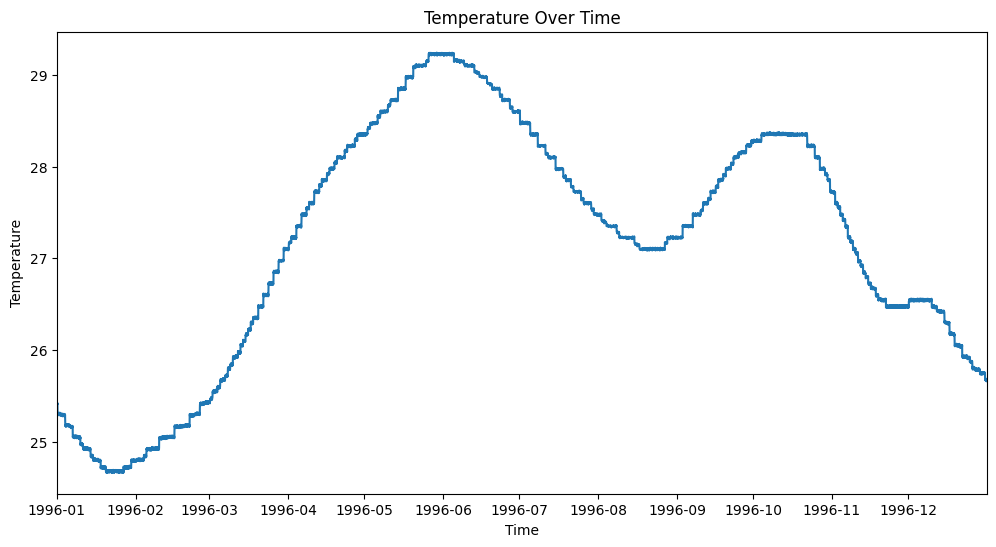

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['Time'],df['Temperature'])
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title('Temperature Over Time')
plt.xlim(df['Time'].min(),df['Time'].max())
plt.show()

# **Combine the data from 1996 to 2019 in a single file**

Missing values: 0 (0.00%)


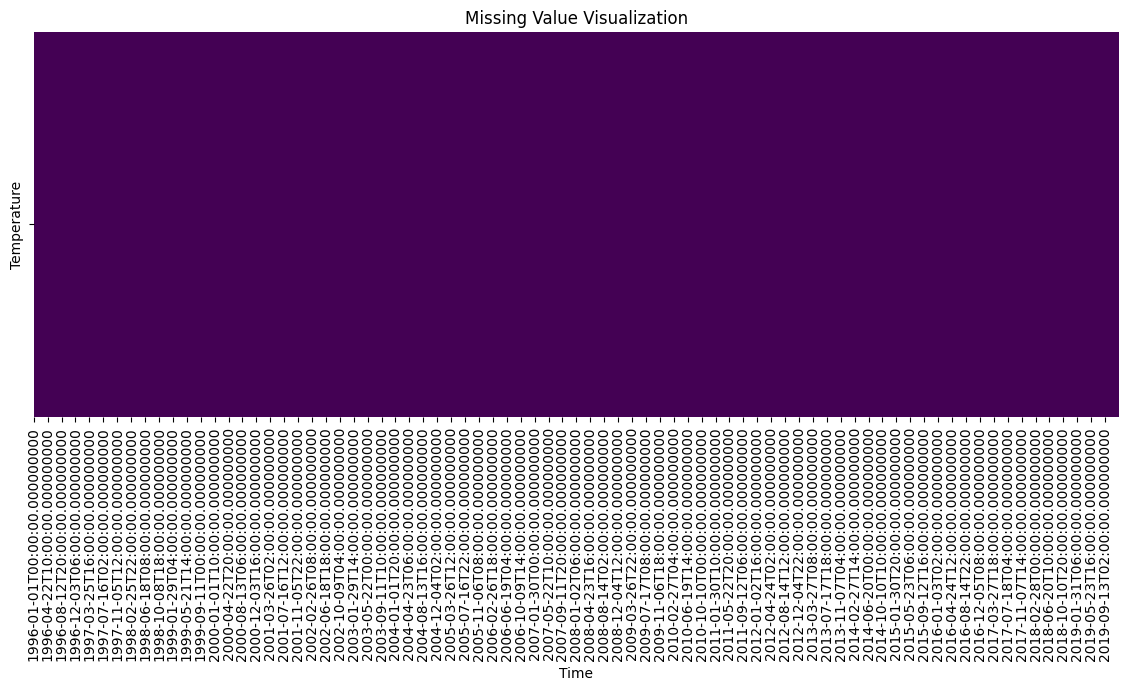

<ipython-input-2-1406347220>:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Temperature'].fillna(method='ffill', inplace=True)
<ipython-input-2-1406347220>:46: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Temperature'].fillna(method='ffill', inplace=True)


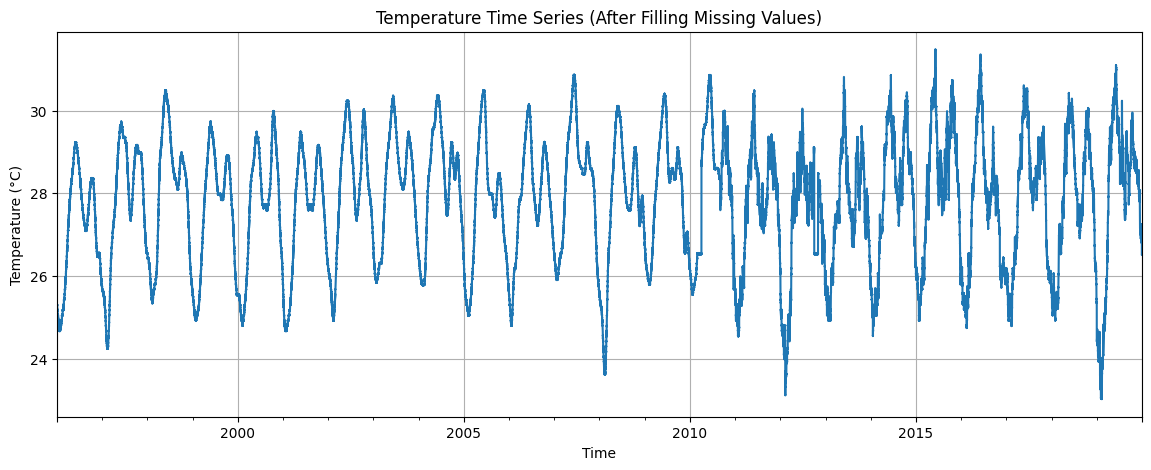

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# --- Step 1: Define location and path ---
location = "19.32_72.72"
data_root = "/content/drive/MyDrive/Dataset/Data/tmp"
years = [str(year) for year in range(1996, 2020)]

# --- Step 2: Read and combine all files for this location ---
df_list = []

for year in years:
    file_path = os.path.join(data_root, year, f"{year}_{location}.csv")
    if os.path.exists(file_path):
        df_year = pd.read_csv(file_path)
        df_list.append(df_year)

# Combine all years into one DataFrame
df = pd.concat(df_list, ignore_index=True)

# --- Step 3: Preprocess the time column ---
df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)
df.sort_index(inplace=True)

# --- Step 4: Check and visualize missing values ---
missing_count = df['Temperature'].isna().sum()
print(f"Missing values: {missing_count} ({(missing_count / len(df)) * 100:.2f}%)")

# Plot missing values
plt.figure(figsize=(14, 5))
sns.heatmap(df.isna().T, cbar=False, cmap='viridis')
plt.title("Missing Value Visualization")
plt.show()

# --- Step 5: Fill missing values (Linear Interpolation) ---
df['Temperature'] = df['Temperature'].interpolate(method='linear')

# Optional: Forward fill remaining NaNs (if any exist at start)
df['Temperature'].fillna(method='ffill', inplace=True)

# --- Step 6: Visualize filled data ---
plt.figure(figsize=(14, 5))
df['Temperature'].plot(title="Temperature Time Series (After Filling Missing Values)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [11]:
# --- Step 7: Normalize temperature values (Min-Max Scaling) ---
scaler = MinMaxScaler()
df['Temperature'] = scaler.fit_transform(df[['Temperature']])

# --- Step 8: Prepare data for LSTM model (supervised learning) ---
def create_sequences(data, sequence_length=24):
    x, y = [], []
    for i in range(len(data) - sequence_length):
        x.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(x), np.array(y)

sequence_length = 24  # Use 24 hours to predict next hour
temperature_array = df['Temperature'].values
X, y = create_sequences(temperature_array, sequence_length)

# --- Step 9: Reshape for LSTM: (samples, timesteps, features) ---
X = X.reshape((X.shape[0], X.shape[1], 1))

# --- Step 10: Train-test split ---
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - loss: 0.0041 - val_loss: 5.6275e-05
Epoch 2/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 80s 15ms/step - loss: 2.1503e-05 - val_loss: 4.5948e-05
Epoch 3/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 1.8906e-05 - val_loss: 3.5410e-05
Epoch 4/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - loss: 1.7597e-05 - val_loss: 3.4659e-05
Epoch 5/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 1.8094e-05 - val_loss: 3.3250e-05
Epoch 6/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - loss: 1.4767e-05 - val_loss: 2.7718e-05
Epoch 7/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - loss: 1.2712e-05 - val_loss: 2.6337e-05
Epoch 8/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - loss: 1.1032e-05 - val_loss: 2.6412e-05
Epoch 9/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - loss: 1.1999e-05 - val_loss: 2.4927e-05
Epoch 10/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - loss: 1.1752e-05 - val_loss: 2.5260e-05
1315/1315 ━━━━━━━━━━━━━

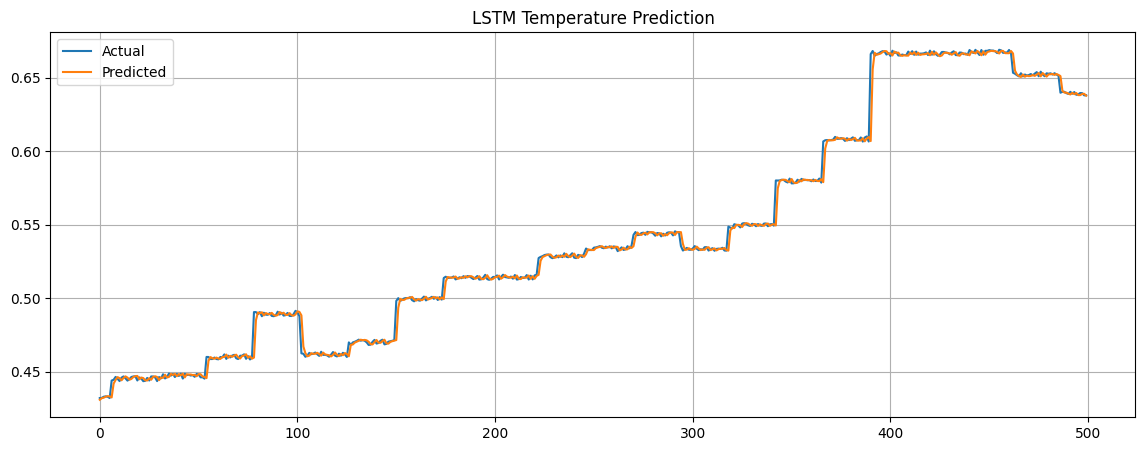

In [ ]:
# --- Step 11: Build LSTM model ---
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# --- Step 12: Train the model ---
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

# --- Step 13: Evaluate the model ---
predicted = model.predict(X_test)
plt.figure(figsize=(14,5))
plt.plot(y_test[:500], label='Actual')
plt.plot(predicted[:500], label='Predicted')
plt.title("LSTM Temperature Prediction")
plt.legend()
plt.grid(True)
plt.show()

Missing values: 0 (0.00%)


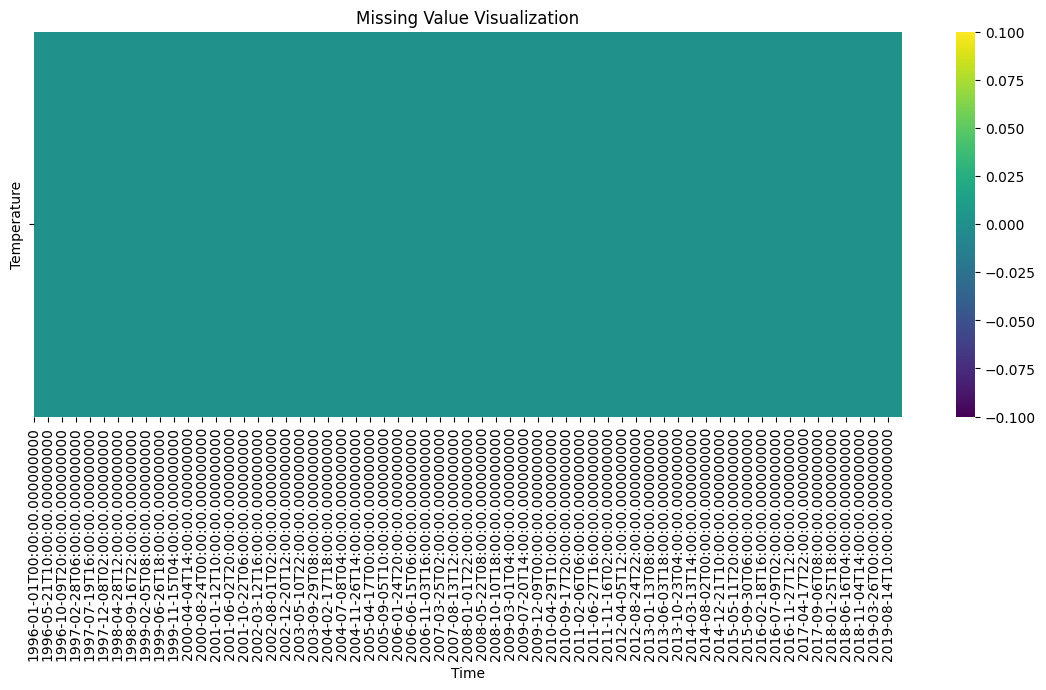

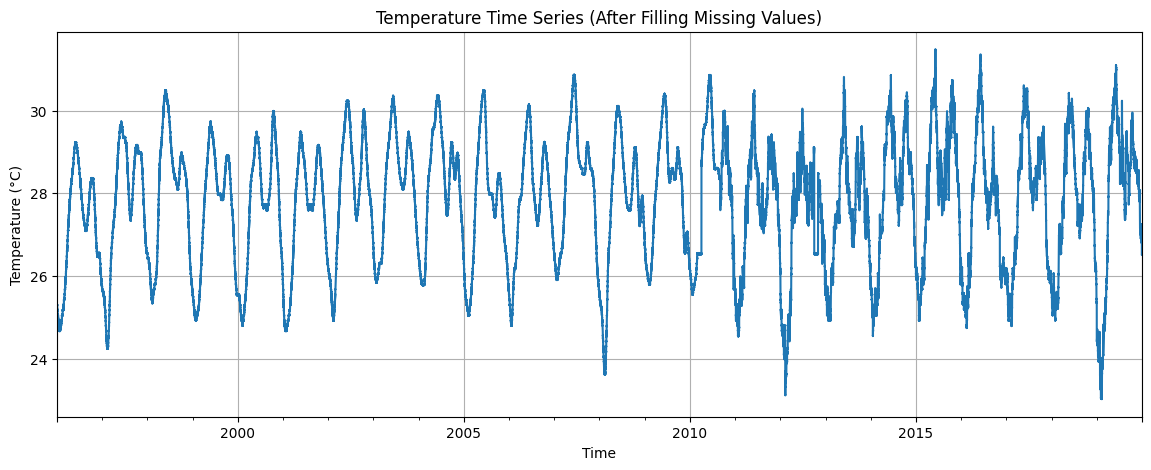

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# --- Step 1: Define location and path ---
location = "19.32_72.72"
data_root = "/content/drive/MyDrive/Dataset/Data/tmp"
years = [str(year) for year in range(1996, 2020)]

# --- Step 2: Read and combine all files for this location ---
df_list = []

for year in years:
    file_path = os.path.join(data_root, year, f"{year}_{location}.csv")
    if os.path.exists(file_path):
        df_year = pd.read_csv(file_path)
        df_list.append(df_year)

# Combine all years into one DataFrame
df = pd.concat(df_list, ignore_index=True)

# --- Step 3: Preprocess the time column ---
df['Time'] = pd.to_datetime(df['Time'])
df.set_index('Time', inplace=True)
df.sort_index(inplace=True)

# --- Step 4: Check and visualize missing values ---
missing_count = df['Temperature'].isna().sum()
print(f"Missing values: {missing_count} ({(missing_count / len(df)) * 100:.2f}%)")

# Plot missing values
plt.figure(figsize=(14, 5))
sns.heatmap(df.isna().T, cbar=True, cmap='viridis')
plt.title("Missing Value Visualization")
plt.show()

# --- Step 5: Fill missing values (Linear Interpolation) ---
original_temps = df['Temperature'].copy()  # Store original values before normalization
df['Temperature'] = df['Temperature'].interpolate(method='linear')

# Optional: Forward fill remaining NaNs (if any exist at start)
df['Temperature'] = df['Temperature'].ffill()
print()
# --- Step 6: Visualize filled data ---
plt.figure(figsize=(14, 5))
df['Temperature'].plot(title="Temperature Time Series (After Filling Missing Values)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [8]:
# --- Step 7: Normalize temperature values (Min-Max Scaling) ---
scaler = MinMaxScaler()
df['Temperature_normalized'] = scaler.fit_transform(df[['Temperature']])  # Keep normalized values in new column
df['Temperature'] = original_temps  # Restore original values

# --- Step 8: Prepare data for LSTM model (supervised learning) ---
def create_sequences(data, sequence_length=24):
    x, y = [], []
    for i in range(len(data) - sequence_length):
        x.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(x), np.array(y)

sequence_length = 24  # Use 24 hours to predict next hour
temperature_array = df['Temperature_normalized'].values
X, y = create_sequences(temperature_array, sequence_length)

# --- Step 9: Reshape for LSTM: (samples, timesteps, features) ---
X = X.reshape((X.shape[0], X.shape[1], 1))

# --- Step 10: Train-test split ---
split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 50s 18ms/step - loss: 0.0054 - val_loss: 5.6048e-05
Epoch 2/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 78s 17ms/step - loss: 2.0280e-05 - val_loss: 4.3855e-05
Epoch 3/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 1.7077e-05 - val_loss: 3.2664e-05
Epoch 4/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 1.5702e-05 - val_loss: 3.7555e-05
Epoch 5/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 1.4492e-05 - val_loss: 2.8136e-05
Epoch 6/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 1.4012e-05 - val_loss: 2.8258e-05
Epoch 7/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 45s 17ms/step - loss: 1.4033e-05 - val_loss: 2.5641e-05
Epoch 8/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 1.3117e-05 - val_loss: 2.7063e-05
Epoch 9/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 1.3089e-05 - val_loss: 2.5556e-05
Epoch 10/10
2630/2630 ━━━━━━━━━━━━━━━━━━━━ 84s 18ms/step - loss: 1.1971e-05 - val_loss: 2.4852e-05
1315/1315 ━━━━━━━━━━━━━

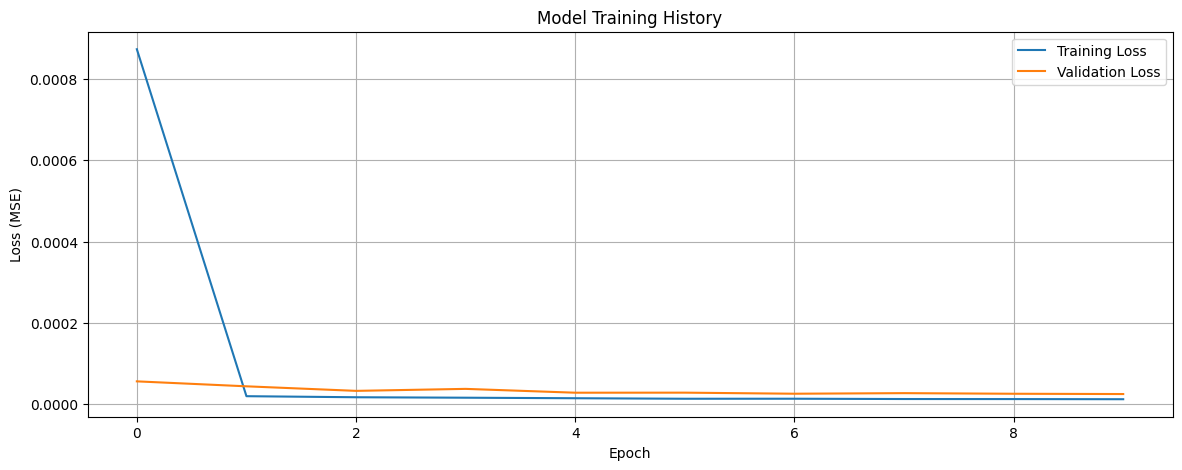

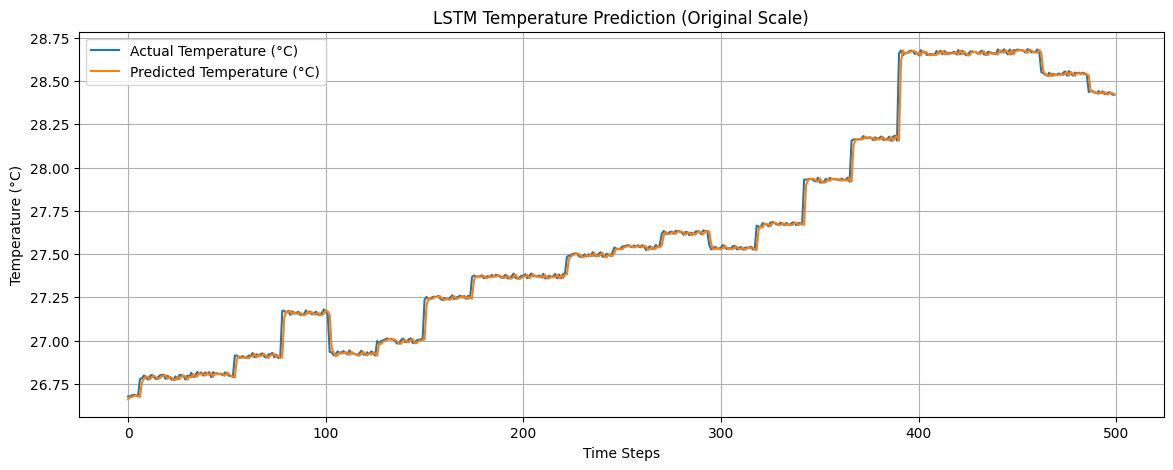


Model Evaluation Metrics (Original Scale):
Mean Absolute Error: 0.02°C
Root Mean Squared Error: 0.04°C

Sample Predictions:
                        Actual  Predicted
Time                                     
2015-03-15 00:00:00  26.676721  26.660994
2015-03-15 01:00:00  26.677606  26.670954
2015-03-15 02:00:00  26.684351  26.673409
2015-03-15 03:00:00  26.686243  26.679605
2015-03-15 04:00:00  26.684015  26.682280
2015-03-15 05:00:00  26.676965  26.680815
2015-03-15 06:00:00  26.777582  26.674541
2015-03-15 07:00:00  26.781946  26.759192
2015-03-15 08:00:00  26.798578  26.776890
2015-03-15 09:00:00  26.787378  26.793854


In [9]:
# --- Step 11: Build LSTM model ---
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# --- Step 12: Train the model ---
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

# --- Step 13: Evaluate the model ---
# Get predictions (normalized)
predicted_normalized = model.predict(X_test)

# Convert predictions back to original scale
predicted_original = scaler.inverse_transform(predicted_normalized)
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot training history
plt.figure(figsize=(14, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

print()

# Plot predictions vs actual in original scale
plt.figure(figsize=(14, 5))
plt.plot(y_test_original[:500], label='Actual Temperature (°C)')
plt.plot(predicted_original[:500], label='Predicted Temperature (°C)')
plt.title("LSTM Temperature Prediction (Original Scale)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Time Steps")
plt.legend()
plt.grid(True)
plt.show()

# Create DataFrame with actual vs predicted values
results_df = pd.DataFrame({
    'Actual': y_test_original.flatten(),
    'Predicted': predicted_original.flatten()
}, index=df.index[-len(y_test_original):])

# Calculate and print evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_original, predicted_original)
rmse = np.sqrt(mean_squared_error(y_test_original, predicted_original))

print(f"\nModel Evaluation Metrics (Original Scale):")
print(f"Mean Absolute Error: {mae:.2f}°C")
print(f"Root Mean Squared Error: {rmse:.2f}°C")

# Show sample of actual vs predicted values
print("\nSample Predictions:")
print(results_df.head(10))